In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
df_items=order_item_df = pd.read_csv('dataset/olist_order_items_dataset.csv')
order_payment_df = pd.read_csv('dataset/olist_order_payments_dataset.csv')
order_review_df = pd.read_csv('dataset/olist_order_reviews_dataset.csv')
orders_df = pd.read_csv('dataset/olist_orders_dataset.csv')

# Order Volumes, Revenue and Review Scores

In [22]:
# Let's inspect olist_order_items_dataset.csv more deeply
print("Shape:", order_item_df.shape)
print(order_item_df.head())
print("Min/Max shipping limit date:", order_item_df['shipping_limit_date'].min(), order_item_df['shipping_limit_date'].max())

Shape: (112650, 8)
                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   

  shipping_limit_date   price  freight_value year_month  
0 2017-09-19 09:45:35   58.90          13.29    2017-09  
1 2017-05-03 11:05:13  239.90          19.93    2017-05  
2 2018-01-18 14:48:30  199.00          17.8

In [24]:
# Let's check the date range and monthly aggregation of order volume and revenue from olist_order_items_dataset.csv
df_items['shipping_limit_date'] = pd.to_datetime(df_items['shipping_limit_date'])
df_items['year_month'] = df_items['shipping_limit_date'].dt.to_period('M')
monthly_summary = df_items.groupby('year_month').agg(
    order_volume=('order_id', 'nunique'),
    total_revenue=('price', 'sum'),
    item_count=('order_item_id', 'count')
).reset_index()
print(monthly_summary)

   year_month  order_volume  total_revenue  item_count
0     2016-09             2         194.47           4
1     2016-10           309       49580.55         365
2     2016-12             1          10.90           1
3     2017-01           573       80124.74         681
4     2017-02          1650      245982.01        1866
5     2017-03          2401      343242.60        2751
6     2017-04          2111      308148.32        2364
7     2017-05          3674      505655.46        4150
8     2017-06          3385      469001.05        3801
9     2017-07          3643      465282.10        4116
10    2017-08          4403      560093.34        5042
11    2017-09          4165      617046.12        4724
12    2017-10          4490      658020.23        5189
13    2017-11          6314      883351.63        7355
14    2017-12          6772      898920.98        7726
15    2018-01          6656      845279.18        7492
16    2018-02          6450      819228.85        7375
17    2018

Chart generated and saved successfully.


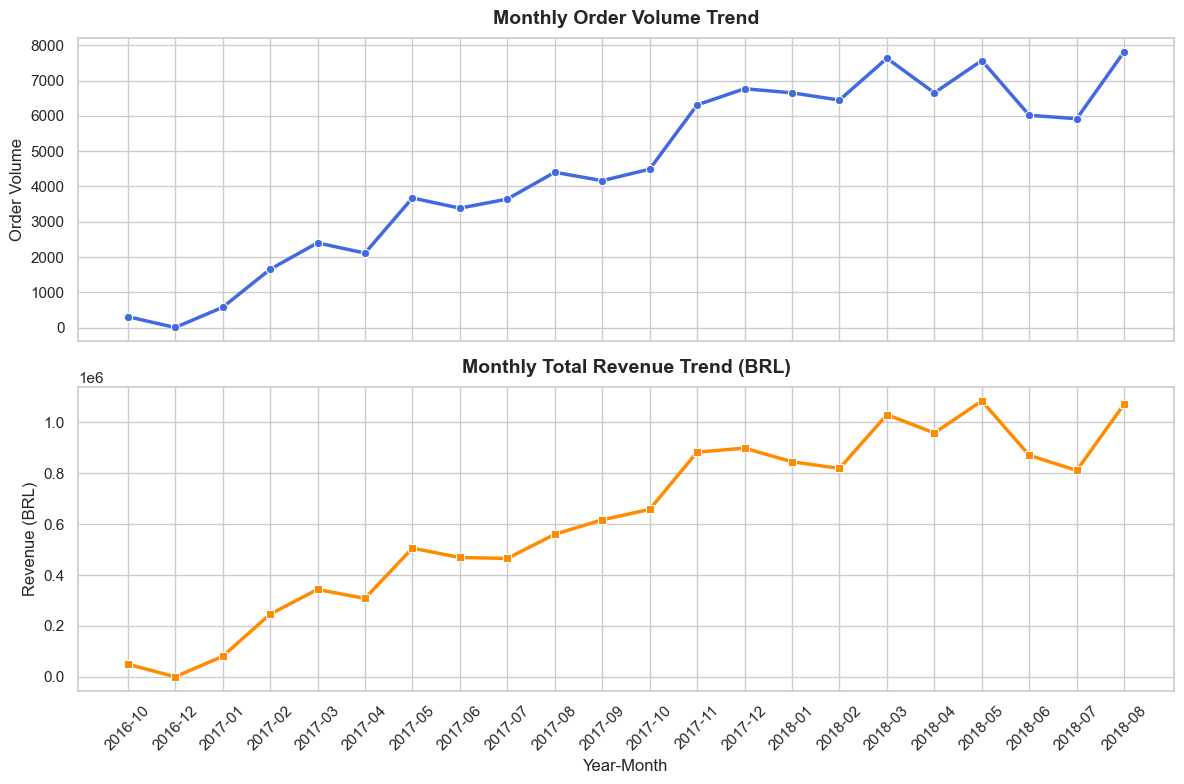

In [26]:
# Load data and aggregate monthly
df_items['shipping_limit_date'] = pd.to_datetime(df_items['shipping_limit_date'])
df_items['year_month'] = df_items['shipping_limit_date'].dt.to_period('M')

monthly_summary = df_items.groupby('year_month').agg(
    order_volume=('order_id', 'nunique'),
    total_revenue=('price', 'sum')
).reset_index()

# Filter out the tail ends or keep active period (e.g., Oct 2016 to Aug 2018)
monthly_summary['year_month_str'] = monthly_summary['year_month'].astype(str)
active_summary = monthly_summary[(monthly_summary['year_month_str'] >= '2016-10') & (monthly_summary['year_month_str'] <= '2018-08')]

# Set style
sns.set_theme(style="whitegrid")

# Create figure with 2 subplots (Order Volume and Revenue)
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot Order Volume
sns.lineplot(
    data=active_summary, 
    x='year_month_str', 
    y='order_volume', 
    ax=axes[0], 
    color='royalblue', 
    marker='o', 
    linewidth=2.5
)
axes[0].set_title('Monthly Order Volume Trend', fontsize=14, fontweight='bold', pad=10)
axes[0].set_ylabel('Order Volume', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Plot Total Revenue
sns.lineplot(
    data=active_summary, 
    x='year_month_str', 
    y='total_revenue', 
    ax=axes[1], 
    color='darkorange', 
    marker='s', 
    linewidth=2.5
)
axes[1].set_title('Monthly Total Revenue Trend (BRL)', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Year-Month', fontsize=12)
axes[1].set_ylabel('Revenue (BRL)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('olist_trends.png', dpi=300)
print("Chart generated and saved successfully.")

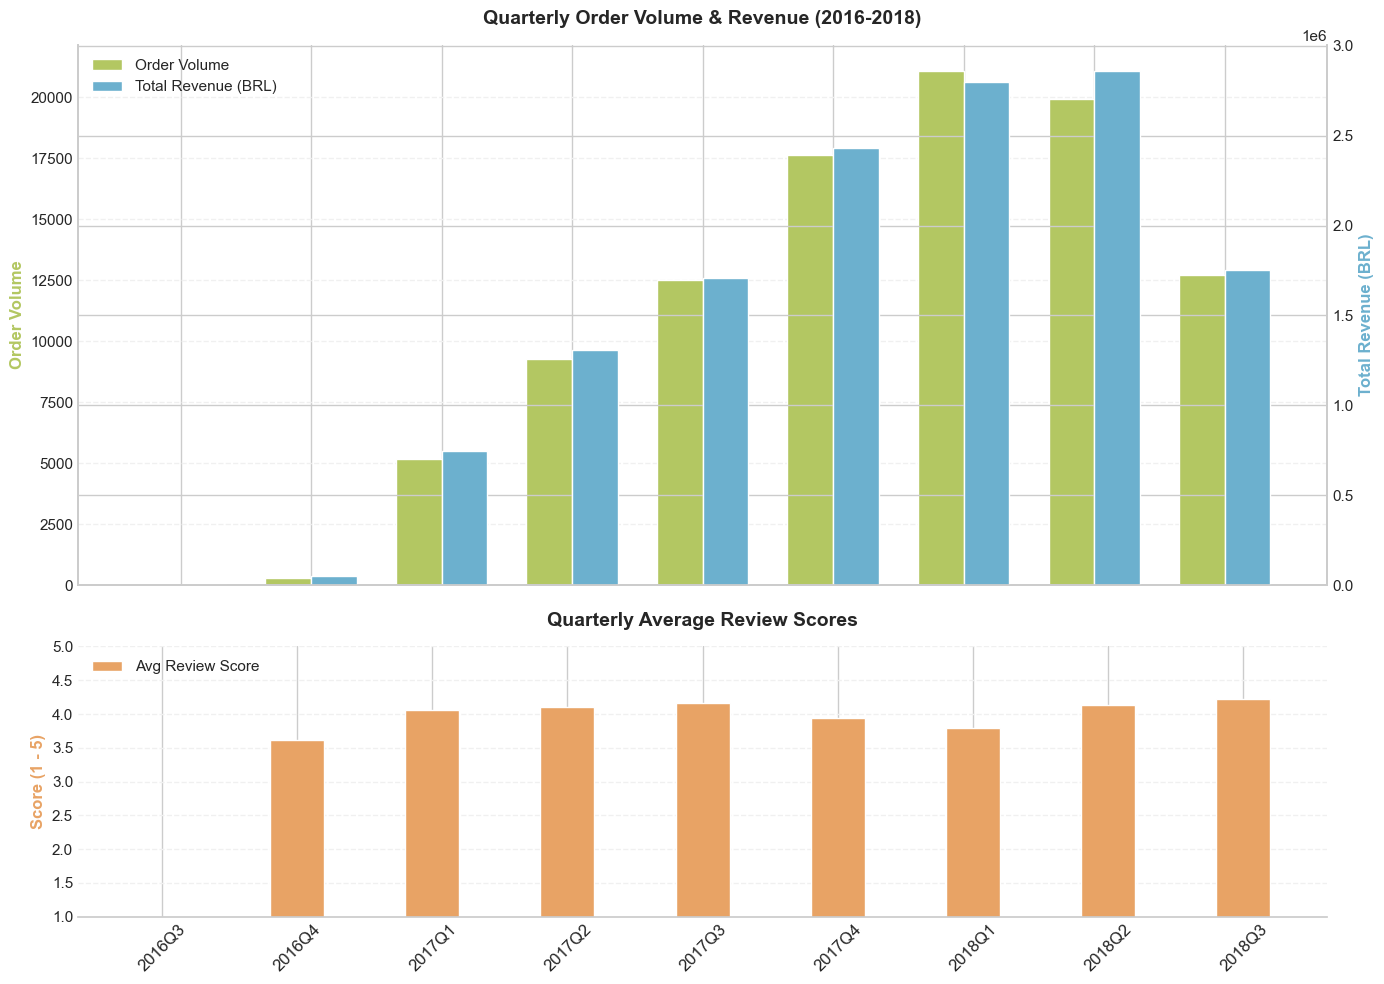

In [33]:
# 1. Define Dataset Paths (Update datasetPath to your local directory)
datasetPath = "dataset/" 
datasetsCSV: dict = {
    "orders": datasetPath + "olist_orders_dataset.csv",
    "orderItems": datasetPath + "olist_order_items_dataset.csv",
    "orderReviews": datasetPath + "olist_order_reviews_dataset.csv"
}

# 2. Load the required DataFrames
orders_df = pd.read_csv(datasetsCSV["orders"])
orderItems_df = pd.read_csv(datasetsCSV["orderItems"])
orderReviews_df = pd.read_csv(datasetsCSV["orderReviews"])

# 3. Merge the DataFrames on order_id
df_merged = orders_df[['order_id', 'order_purchase_timestamp']].merge(
    orderItems_df[['order_id', 'price']], on='order_id', how='inner'
).merge(
    orderReviews_df[['order_id', 'review_score']], on='order_id', how='left'
)

# 4. Filter for 2016 to 2018 and extract the quarter
df_merged['order_purchase_timestamp'] = pd.to_datetime(df_merged['order_purchase_timestamp'])
df_filtered = df_merged[
    (df_merged['order_purchase_timestamp'].dt.year >= 2016) & 
    (df_merged['order_purchase_timestamp'].dt.year <= 2018)
].copy()

df_filtered['quarter'] = df_filtered['order_purchase_timestamp'].dt.to_period('Q')

# 5. Group by quarter and aggregate metrics
grouped = df_filtered.groupby('quarter').agg(
    order_volume=('order_id', 'nunique'),
    total_revenue=('price', 'sum'),
    avg_review=('review_score', 'mean')
).reset_index()

grouped['quarter_str'] = grouped['quarter'].astype(str)

# 6. Plotting Setup: 2 Subplots (Top: Vol & Rev, Bottom: Scores)
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

x = np.arange(len(grouped['quarter_str']))
width = 0.35  # Bar width

# Standardized Color Palette
color_vol = '#b3c762'   # Olive Green
color_rev = '#6cb0ce'   # Light Blue
color_score = '#e8a365' # Warm Orange

# ==========================================
# TOP PLOT: Order Volume & Revenue (Dual Y-Axis)
# ==========================================
ax1 = axes[0]
ax2 = ax1.twinx()  # Create a secondary Y-axis for revenue

# Plot side-by-side bars
rects1 = ax1.bar(x - width/2, grouped['order_volume'], width, label='Order Volume', color=color_vol, edgecolor='white')
rects2 = ax2.bar(x + width/2, grouped['total_revenue'], width, label='Total Revenue (BRL)', color=color_rev, edgecolor='white')

# Titles and Labels
ax1.set_title('Quarterly Order Volume & Revenue (2016-2018)', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('Order Volume', fontsize=12, color=color_vol, fontweight='bold')
ax2.set_ylabel('Total Revenue (BRL)', fontsize=12, color=color_rev, fontweight='bold')

# Axis formatting
ax1.set_xticks(x)
ax1.set_xticklabels([]) # Hide X-labels on the top plot to avoid clutter
ax1.yaxis.grid(True, linestyle='--', color='#f0f0f0', alpha=1.0)
ax1.set_axisbelow(True)

# Combine legends for the dual axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=False, fontsize=11)

# Clean borders
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.tick_params(axis='both', which='both', length=0)

# ==========================================
# BOTTOM PLOT: Average Review Scores
# ==========================================
ax3 = axes[1]
rects3 = ax3.bar(x, grouped['avg_review'], width=0.4, color=color_score, edgecolor='white', label='Avg Review Score')

# Titles and Labels
ax3.set_title('Quarterly Average Review Scores', fontsize=14, fontweight='bold', pad=15)
ax3.set_ylabel('Score (1 - 5)', fontsize=12, color=color_score, fontweight='bold')
ax3.set_ylim(1, 5) # Lock scale to real review bounds

# Axis formatting
ax3.set_xticks(x)
ax3.set_xticklabels(grouped['quarter_str'], fontsize=12, rotation=45)
ax3.yaxis.grid(True, linestyle='--', color='#f0f0f0', alpha=1.0)
ax3.set_axisbelow(True)

# Clean borders
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.tick_params(axis='both', which='both', length=0)
ax3.legend(loc='upper left', frameon=False, fontsize=11)

plt.tight_layout()
plt.show()